# Benchmarking Multimodal Semantic Alignment Between Speech and Text Representations in the Igbo Language
### Dataset: WAXAL (`google/WaxalNLP` · Igbo TTS · Media Trust)
### Loading method: Direct parquet download via `huggingface_hub` (no `load_dataset`)

---

## Dataset Facts (confirmed)

| Property | Value |
|---|---|
| Source | `google/WaxalNLP` · `data/TTS/ibo/` |
| Provider | Media Trust Nigeria |
| License | CC-BY-4.0 |
| Total records | 1,911 |
| Fields | `id`, `speaker_id`, `text`, `locale`, `gender`, `audio` |
| Audio format | MP3 bytes (embedded in parquet) |
| Text field | `text` |

## Pipeline

```
Parquet files (cached locally)
        │
        ├── audio bytes ──► decode MP3 ──► 16kHz float32
        │                        │
        │               Whisper-tiny encoder
        │               mean-pool hidden states
        │                        │
        │               Speech embeddings (N × 384)
        │                        │
        └── text ────────────────┤
                        Multilingual MiniLM
                                 │
                        Text embeddings (N × 384)
                                 │
                  ───────────────┴───────────────
                  Cosine similarity + InfoNCE projection
                  Recall@K · MRR · Error analysis
```

---
## STEP 1 — Environment Setup

In [1]:
# # ============================================================
# # CELL 1A — Installs (run once, then comment out)
# # ============================================================

# # CPU-only PyTorch
# !pip install torch==2.1.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cpu

# # Core libraries
# !pip install --upgrade pyarrow
# !pip install --upgrade huggingface_hub
# !pip install transformers==4.40.0
# !pip install sentence-transformers==2.7.0
# !pip install librosa soundfile
# !pip install tqdm numpy pandas matplotlib seaborn scikit-learn scipy

# import sys
# print(f"Python: {sys.version}")

In [2]:
# ============================================================
# CELL 1B — CPU thread settings (set BEFORE importing torch)
# ============================================================

import os

# Set to (your physical CPU core count - 1)
# Check with: os.cpu_count()
NUM_THREADS = 4

os.environ["OMP_NUM_THREADS"]        = str(NUM_THREADS)
os.environ["MKL_NUM_THREADS"]        = str(NUM_THREADS)
os.environ["OPENBLAS_NUM_THREADS"]   = str(NUM_THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
torch.set_num_threads(NUM_THREADS)
torch.set_num_interop_threads(2)

DEVICE = torch.device("cpu")
print(f"PyTorch       : {torch.__version__}")
print(f"Device        : {DEVICE}")
print(f"CPU threads   : {torch.get_num_threads()}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch       : 2.1.2+cpu
Device        : cpu
CPU threads   : 4
CUDA available: False


In [3]:
# ============================================================
# CELL 1C — Global imports and constants
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import io
import re
import gc
import json
import time
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy import stats as scipy_stats

import librosa
import soundfile as sf

from huggingface_hub import hf_hub_download, login
from transformers import WhisperFeatureExtractor, WhisperModel
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

# ── Reproducibility ───────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Directories ───────────────────────────────────────────
CACHE_DIR = Path("./cache")
EMBED_DIR = Path("./embeddings")
CACHE_DIR.mkdir(exist_ok=True)
EMBED_DIR.mkdir(exist_ok=True)

# ── Audio constants ───────────────────────────────────────
TARGET_SR   = 16_000          # Whisper requires 16 kHz
MAX_SAMPLES = TARGET_SR * 30  # 30-second encoder window cap

print("All imports successful.")

All imports successful.


---
## STEP 2 — Authentication & Data Loading

Files are already cached from the download step.  
`hf_hub_download` detects the local cache and skips re-downloading.

In [4]:
# ============================================================
# CELL 2A — Authenticate with HuggingFace
# ============================================================

TOKEN_PATH = r"C:\Users\Chidiebere\Documents\IgboTTS\hf_token.txt"

with open(TOKEN_PATH, "r") as f:
    hf_token = f.read().strip()

login(hf_token)
print("Authenticated.")

Authenticated.


In [5]:
# ============================================================
# CELL 2B — Load parquet files from local cache
# No re-download: hf_hub_download reads from cache automatically
# ============================================================

PARQUET_FILES = [
    "data/TTS/ibo/ibo-train-00000.parquet",
    "data/TTS/ibo/ibo-train-00001.parquet",
    "data/TTS/ibo/ibo-validation-00000.parquet",
    "data/TTS/ibo/ibo-test-00000.parquet",
]

dfs = []
for fname in PARQUET_FILES:
    local_path = hf_hub_download(
        repo_id="google/WaxalNLP",
        filename=fname,
        repo_type="dataset",
        token=hf_token,
    )
    dfs.append(pd.read_parquet(local_path))
    print(f"Loaded: {fname}  ({len(dfs[-1])} rows)")

df_waxal = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(f"\nTotal records  : {len(df_waxal)}")
print(f"Columns        : {list(df_waxal.columns)}")
print(f"Locale values  : {df_waxal['locale'].unique()}")
print(f"Gender counts  :\n{df_waxal['gender'].value_counts().to_string()}")

Loaded: data/TTS/ibo/ibo-train-00000.parquet  (965 rows)
Loaded: data/TTS/ibo/ibo-train-00001.parquet  (587 rows)
Loaded: data/TTS/ibo/ibo-validation-00000.parquet  (159 rows)
Loaded: data/TTS/ibo/ibo-test-00000.parquet  (200 rows)

Total records  : 1911
Columns        : ['id', 'speaker_id', 'text', 'locale', 'gender', 'audio']
Locale values  : ['ibo']
Gender counts  :
gender
Female    962
Male      949


---
## STEP 3 — Audio Decoding & Data Extraction

WAXAL stores audio as **MP3 bytes** inside the parquet file.  
We decode each row's bytes → numpy float32 array using `librosa`.

In [6]:
# ============================================================
# CELL 3A — Inspect the audio field structure
# ============================================================

sample_row = df_waxal.iloc[0]

print("Sample record:")
print(f"  id         : {sample_row['id']}")
print(f"  speaker_id : {sample_row['speaker_id']}")
print(f"  locale     : {sample_row['locale']}")
print(f"  gender     : {sample_row['gender']}")
print(f"  text       : {sample_row['text']}")
print(f"  audio type : {type(sample_row['audio'])}")

# The audio field is a dict with a 'bytes' key containing raw MP3 bytes
audio_field = sample_row['audio']
print(f"  audio keys : {list(audio_field.keys()) if isinstance(audio_field, dict) else 'raw bytes'}")

# Extract bytes
if isinstance(audio_field, dict):
    audio_bytes = audio_field['bytes']
else:
    audio_bytes = audio_field

print(f"  bytes len  : {len(audio_bytes):,} bytes")
print(f"  header     : {audio_bytes[:3]}  (ID3 = MP3 confirmed)")

Sample record:
  id         : ibo_14
  speaker_id : 1
  locale     : ibo
  gender     : Female
  text       : Nwoke Na- agba Boolu
  audio type : <class 'dict'>
  audio keys : ['bytes', 'path']
  bytes len  : 80,684 bytes
  header     : b'ID3'  (ID3 = MP3 confirmed)


In [7]:
# ============================================================
# CELL 3B — MP3 byte decoder
# Uses librosa to decode in-memory MP3 bytes → float32 array
# No temp files written to disk
# ============================================================

def decode_audio_bytes(audio_field) -> tuple[np.ndarray, int]:
    """
    Decode audio stored as MP3 bytes in a WAXAL parquet row.

    Args:
        audio_field: dict with 'bytes' key, or raw bytes

    Returns:
        (audio_array: np.ndarray float32, sample_rate: int)
    """
    # Extract raw bytes
    raw = audio_field['bytes'] if isinstance(audio_field, dict) else audio_field

    # Wrap bytes in an in-memory file object
    buf = io.BytesIO(raw)

    # librosa decodes MP3 natively via soundfile/audioread
    # sr=None preserves the original sample rate
    audio_arr, sr = librosa.load(buf, sr=None, mono=True)
    return audio_arr.astype(np.float32), sr


# Verify on the first sample
arr, sr = decode_audio_bytes(sample_row['audio'])
duration = len(arr) / sr
print(f"Decoded sample:")
print(f"  Shape    : {arr.shape}")
print(f"  SR       : {sr} Hz")
print(f"  Duration : {duration:.2f}s")
print(f"  Range    : [{arr.min():.4f}, {arr.max():.4f}]")
print(f"  Dtype    : {arr.dtype}")

Decoded sample:
  Shape    : (241920,)
  SR       : 48000 Hz
  Duration : 5.04s
  Range    : [-0.3439, 0.4491]
  Dtype    : float32


In [8]:
# ============================================================
# CELL 3C — Extract all records into a clean list of dicts
# Decode audio + validate each sample in one pass
# ============================================================

def extract_all_records(df: pd.DataFrame) -> list:
    """
    Decode and validate all rows in the WAXAL Igbo dataframe.

    Filters out:
      - Clips shorter than 0.5s (too little acoustic info)
      - Clips longer than 30s  (Whisper encoder limit)
      - Rows with empty text

    Returns list of dicts:
      { audio, sr, text, duration, speaker_id, gender, id }
    """
    records = []
    skipped = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Decoding audio"):
        text = str(row['text']).strip()
        if not text or len(text) < 3:
            skipped += 1
            continue

        try:
            audio_arr, sr = decode_audio_bytes(row['audio'])
        except Exception as e:
            skipped += 1
            continue

        duration = len(audio_arr) / sr
        if duration < 0.5 or duration > 30.0:
            skipped += 1
            continue

        records.append({
            "id"         : row['id'],
            "audio"      : audio_arr,
            "sr"         : sr,
            "text"       : text,
            "duration"   : round(duration, 3),
            "speaker_id" : str(row['speaker_id']),
            "gender"     : str(row['gender']),
        })

    print(f"\nExtracted : {len(records)} valid records")
    print(f"Skipped   : {skipped} (too short/long or empty text)")
    return records


print("Decoding all WAXAL Igbo audio...")
print("(This takes 5–15 minutes depending on CPU speed)\n")

all_records = extract_all_records(df_waxal)

# Free the dataframe — audio is now in all_records
del df_waxal
gc.collect()

durations = [r['duration'] for r in all_records]
print(f"\nDuration — min: {min(durations):.1f}s | max: {max(durations):.1f}s | mean: {np.mean(durations):.1f}s")
print(f"Unique speakers: {len(set(r['speaker_id'] for r in all_records))}")

Decoding all WAXAL Igbo audio...
(This takes 5–15 minutes depending on CPU speed)



Decoding audio:   0%|          | 0/1911 [00:00<?, ?it/s]


Extracted : 1343 valid records
Skipped   : 568 (too short/long or empty text)

Duration — min: 3.1s | max: 29.8s | mean: 12.3s
Unique speakers: 8


---
## STEP 4 — Subsampling

1,911 samples is very manageable, but we still subsample to keep  
Whisper inference within ~5–10 minutes on CPU.

In [9]:
# ============================================================
# CELL 4A — Stratified subsample by duration bucket
# ============================================================

N_SAMPLES = 700    # Reduce to 300–400 if RAM < 8 GB
                   # Increase to len(all_records) to use everything

def stratified_subsample(records, n, seed=SEED):
    rng = np.random.default_rng(seed)
    if n >= len(records):
        print(f"  n={n} >= total={len(records)}. Using all records.")
        return records.copy()

    durations = np.array([r['duration'] for r in records])
    low, high = np.percentile(durations, [33, 66])

    buckets = {
        "short"  : [r for r in records if r['duration'] <= low],
        "medium" : [r for r in records if low < r['duration'] <= high],
        "long"   : [r for r in records if r['duration'] > high],
    }

    per_bucket = n // 3
    sampled = []
    for label, bucket in buckets.items():
        k = min(per_bucket, len(bucket))
        idx = rng.choice(len(bucket), size=k, replace=False)
        sampled.extend([bucket[i] for i in idx])
        print(f"  {label:6s}: {len(bucket):4d} available → {k} sampled")

    rng.shuffle(sampled)
    return sampled[:n]


print(f"Subsampling {N_SAMPLES} from {len(all_records)} records...\n")
records = stratified_subsample(all_records, N_SAMPLES)

del all_records
gc.collect()

print(f"\nFinal sample: {len(records)} records")

Subsampling 700 from 1343 records...

  short :  443 available → 233 sampled
  medium:  443 available → 233 sampled
  long  :  457 available → 233 sampled

Final sample: 699 records


---
## STEP 5 — Preprocessing

In [10]:
# ============================================================
# CELL 5A — Audio preprocessing
# Resample to 16kHz, peak-normalise, truncate to 30s
# ============================================================

def preprocess_audio(audio_array: np.ndarray, source_sr: int) -> np.ndarray:
    # 1. Resample to 16 kHz (Whisper requirement)
    if source_sr != TARGET_SR:
        audio_array = librosa.resample(
            audio_array, orig_sr=source_sr, target_sr=TARGET_SR
        )
    # 2. Mono safeguard
    if audio_array.ndim > 1:
        audio_array = audio_array.mean(axis=0)
    # 3. Peak normalise to [-1, 1]
    peak = np.abs(audio_array).max()
    if peak > 0:
        audio_array = audio_array / peak
    # 4. Hard truncate at 30s
    return audio_array[:MAX_SAMPLES].astype(np.float32)


print(f"Preprocessing {len(records)} audio clips → {TARGET_SR} Hz...")
for r in tqdm(records, desc="Audio preprocessing"):
    r['audio_processed'] = preprocess_audio(r['audio'], r['sr'])

ex = records[0]
print(f"\nExample after preprocessing:")
print(f"  Shape : {ex['audio_processed'].shape}")
print(f"  Range : [{ex['audio_processed'].min():.4f}, {ex['audio_processed'].max():.4f}]")
print(f"  SR    : {TARGET_SR} Hz")

Preprocessing 699 audio clips → 16000 Hz...


Audio preprocessing:   0%|          | 0/699 [00:00<?, ?it/s]


Example after preprocessing:
  Shape : (238080,)
  Range : [-0.7403, 1.0000]
  SR    : 16000 Hz


In [11]:
# ============================================================
# CELL 5B — Text preprocessing
# Igbo uses Latin script with diacritics (ị, ọ, ụ, ṅ).
# NFC normalisation is critical — it composes diacritic + base
# character into a single Unicode codepoint for consistent
# tokenisation. We preserve all diacritics.
# ============================================================

def preprocess_text(text: str) -> str:
    text = unicodedata.normalize("NFC", text)           # compose diacritics
    text = re.sub(r"[\[\]\(\)\{\}\*\_\~\`\^\#]", "", text)  # strip artifacts
    text = re.sub(r"\s+", " ", text)                    # collapse whitespace
    return text.strip().lower()


for r in records:
    r['text_clean'] = preprocess_text(r['text'])

print("Text preprocessing — before / after (5 samples):")
print("-" * 62)
for i in range(min(5, len(records))):
    print(f"  BEFORE : {records[i]['text']}")
    print(f"  AFTER  : {records[i]['text_clean']}")
    print()

Text preprocessing — before / after (5 samples):
--------------------------------------------------------------
  BEFORE : Akwa Ibom bụ steeti kacha na-emepụta mmanụ na gaasi na Naịjirịa
  AFTER  : akwa ibom bụ steeti kacha na-emepụta mmanụ na gaasi na naịjirịa

  BEFORE : Iko anọ akpụrụ akpụ nọ na ahere, nke na-acha nchara nchara bụ ụzọ, nke na-acha mme mme na-esote, nke na-acha ntụ ntụ na-esote nke kpee azụ na-eji ojii.
  AFTER  : iko anọ akpụrụ akpụ nọ na ahere, nke na-acha nchara nchara bụ ụzọ, nke na-acha mme mme na-esote, nke na-acha ntụ ntụ na-esote nke kpee azụ na-eji ojii.

  BEFORE : Atọ n'ime anọ mụbara otu narị na iri abụọ bụ iri itoolu.
  AFTER  : atọ n'ime anọ mụbara otu narị na iri abụọ bụ iri itoolu.

  BEFORE : Olusegun Obasanjo bụ onyeisi ala Naịjiria mbụ weputara ọkpụkpọ ekwentị n'obodo Naijiria.
  AFTER  : olusegun obasanjo bụ onyeisi ala naịjiria mbụ weputara ọkpụkpọ ekwentị n'obodo naijiria.

  BEFORE : Ahmed Tinubu bụ onye Yoruba sitere na Lagos steeti
  AFTER  :

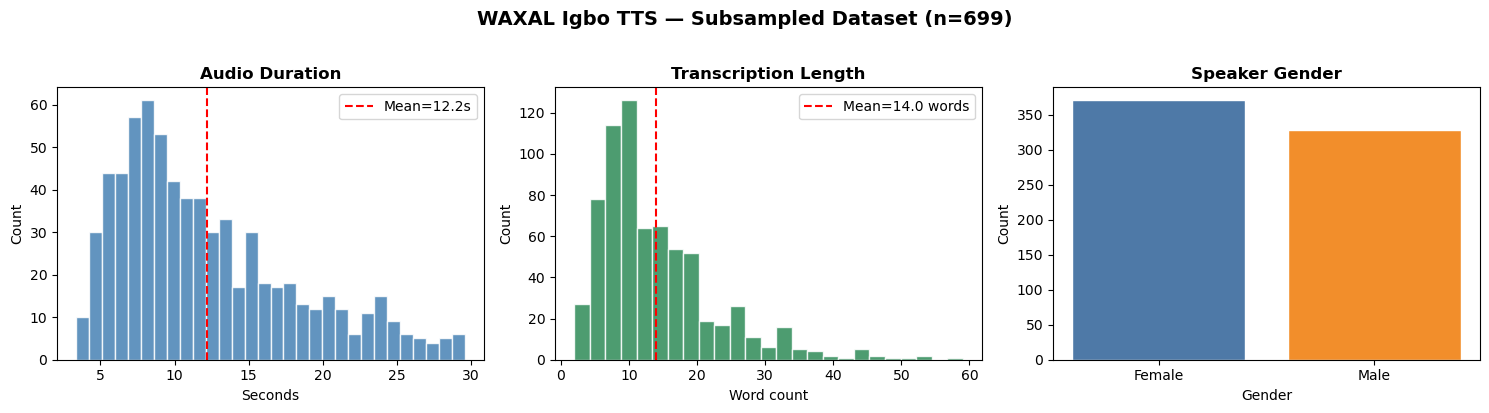

Saved: waxal_dataset_overview.png


In [12]:
# ============================================================
# CELL 5C — Dataset overview plots
# ============================================================

durations = [r['duration'] for r in records]
text_lens = [len(r['text_clean'].split()) for r in records]
genders   = [r['gender'] for r in records]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(durations, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(durations), color='red', linestyle='--',
                label=f'Mean={np.mean(durations):.1f}s')
axes[0].set_title('Audio Duration', fontweight='bold')
axes[0].set_xlabel('Seconds'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(text_lens, bins=25, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(text_lens), color='red', linestyle='--',
                label=f'Mean={np.mean(text_lens):.1f} words')
axes[1].set_title('Transcription Length', fontweight='bold')
axes[1].set_xlabel('Word count'); axes[1].set_ylabel('Count')
axes[1].legend()

gender_counts = pd.Series(genders).value_counts()
axes[2].bar(gender_counts.index, gender_counts.values,
            color=['#4E79A7', '#F28E2B', '#76B7B2'], edgecolor='white')
axes[2].set_title('Speaker Gender', fontweight='bold')
axes[2].set_xlabel('Gender'); axes[2].set_ylabel('Count')

plt.suptitle(f'WAXAL Igbo TTS — Subsampled Dataset (n={len(records)})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('waxal_dataset_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: waxal_dataset_overview.png')

---
## STEP 6 — Model Loading

In [13]:
# ============================================================
# CELL 6A — Whisper-tiny speech encoder
# 39M params, ~75 MB, multilingual, encoder-only inference
# ============================================================

SPEECH_MODEL_ID = 'openai/whisper-tiny'

print(f'Loading: {SPEECH_MODEL_ID}')
whisper_processor = WhisperFeatureExtractor.from_pretrained(
    SPEECH_MODEL_ID, cache_dir=str(CACHE_DIR)
)
whisper_model = WhisperModel.from_pretrained(
    SPEECH_MODEL_ID, cache_dir=str(CACHE_DIR)
).to(DEVICE)
whisper_model.eval()

for p in whisper_model.parameters():
    p.requires_grad_(False)   # freeze — saves ~30% RAM

SPEECH_EMBED_DIM = whisper_model.config.d_model  # 384
print(f'  Encoder dim    : {SPEECH_EMBED_DIM}')
print(f'  Encoder layers : {whisper_model.config.encoder_layers}')

Loading: openai/whisper-tiny
  Encoder dim    : 384
  Encoder layers : 4


In [14]:
# ============================================================
# CELL 6B — Multilingual MiniLM text encoder
# 118M params, 384-dim output, 50+ languages
# ============================================================

TEXT_MODEL_ID = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'

print(f'Loading: {TEXT_MODEL_ID}')
text_encoder = SentenceTransformer(
    TEXT_MODEL_ID, device='cpu', cache_folder=str(CACHE_DIR)
)

TEXT_EMBED_DIM = text_encoder.get_sentence_embedding_dimension()  # 384
print(f'  Output dim : {TEXT_EMBED_DIM}')

# Quick sanity check with an Igbo sentence from the dataset
test = text_encoder.encode(['Nwoke Na- agba Boolu'], normalize_embeddings=True)
print(f'  Test shape : {test.shape}')
print(f'  Test norm  : {np.linalg.norm(test[0]):.4f}  (should be ≈1.0)')

Loading: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  Output dim : 384
  Test shape : (1, 384)
  Test norm  : 1.0000  (should be ≈1.0)


---
## STEP 7 — Embedding Extraction

In [15]:
# ============================================================
# CELL 7A — Speech embedding extraction
#
# Whisper encoder output: (batch, time_frames, d_model)
# We mean-pool over time_frames → (batch, d_model)
# Then L2-normalise → cosine similarity = dot product
# ============================================================

SPEECH_BATCH = 4   # Small: audio tensors are large
                   # Increase to 8 if RAM > 12 GB

def extract_speech_embeddings(records, processor, model, batch_size):
    all_embs = []
    n_batches = (len(records) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in tqdm(range(n_batches), desc='Speech embeddings', unit='batch'):
            batch = records[i * batch_size : (i + 1) * batch_size]

            # ── FIX: Remove padding='longest' and truncation=True ──
            # WhisperFeatureExtractor pads/truncates to exactly 3000
            # mel frames internally. Overriding this with padding=
            # 'longest' pads only to the batch maximum instead of
            # 3000, which causes the encoder to crash.
            inputs = processor(
                [r['audio_processed'] for r in batch],
                sampling_rate=TARGET_SR,
                return_tensors='pt',
            )

            enc  = model.encoder(input_features=inputs.input_features.to(DEVICE))
            embs = enc.last_hidden_state.mean(dim=1).cpu().numpy()
            all_embs.append(embs.astype(np.float32))

            del inputs, enc, embs
            gc.collect()

    return normalize(np.vstack(all_embs), norm='l2')


SPEECH_CACHE = EMBED_DIR / 'waxal_ibo_speech.npy'

if SPEECH_CACHE.exists():
    print(f'Loading cached: {SPEECH_CACHE}')
    speech_embeddings = np.load(SPEECH_CACHE)
else:
    t0 = time.time()
    speech_embeddings = extract_speech_embeddings(
        records, whisper_processor, whisper_model, SPEECH_BATCH
    )
    elapsed = time.time() - t0
    np.save(SPEECH_CACHE, speech_embeddings)
    print(f'Done in {elapsed:.1f}s ({elapsed/len(records):.2f}s/sample)')
    print(f'Saved: {SPEECH_CACHE}')

print(f'Speech embeddings: {speech_embeddings.shape}')

Loading cached: embeddings\waxal_ibo_speech.npy
Speech embeddings: (699, 384)


In [16]:
# ============================================================
# CELL 7B — Text embedding extraction
# ============================================================

TEXT_CACHE = EMBED_DIR / 'waxal_ibo_text.npy'

if TEXT_CACHE.exists():
    print(f'Loading cached: {TEXT_CACHE}')
    text_embeddings = np.load(TEXT_CACHE)
else:
    t0 = time.time()
    text_embeddings = text_encoder.encode(
        [r['text_clean'] for r in records],
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    )
    elapsed = time.time() - t0
    np.save(TEXT_CACHE, text_embeddings)
    print(f'Done in {elapsed:.1f}s')
    print(f'Saved: {TEXT_CACHE}')

print(f'Text embeddings  : {text_embeddings.shape}')

Loading cached: embeddings\waxal_ibo_text.npy
Text embeddings  : (699, 384)


In [17]:
# ============================================================
# CELL 7C — Sanity checks
# ============================================================

assert speech_embeddings.shape == (len(records), SPEECH_EMBED_DIM)
assert text_embeddings.shape   == (len(records), TEXT_EMBED_DIM)

s_norms = np.linalg.norm(speech_embeddings, axis=1)
t_norms = np.linalg.norm(text_embeddings, axis=1)
print(f'Speech norms — mean: {s_norms.mean():.4f} ± {s_norms.std():.5f}  (should be ≈1.0)')
print(f'Text   norms — mean: {t_norms.mean():.4f} ± {t_norms.std():.5f}  (should be ≈1.0)')
print('All checks passed.')

Speech norms — mean: 1.0000 ± 0.00000  (should be ≈1.0)
Text   norms — mean: 1.0000 ± 0.00000  (should be ≈1.0)
All checks passed.


---
## STEP 8 — Cross-Modal Alignment

Similarity matrix shape       : (699, 699)
Diagonal mean (paired)        : -0.0009
Off-diagonal mean (non-paired): -0.0026
Gap (paired – random)         : 0.0017


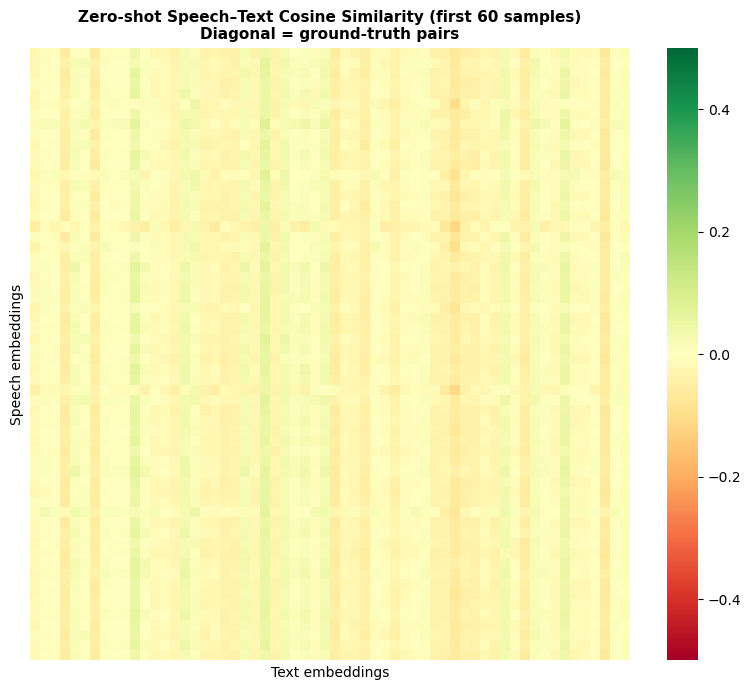

In [18]:
# ============================================================
# CELL 8A — Zero-shot cosine similarity matrix
# Both embeddings are L2-normalised → cosine = dot product
# Diagonal = ground-truth (speech_i, text_i) pairs
# ============================================================

sim_matrix_raw = speech_embeddings @ text_embeddings.T

diag     = np.diag(sim_matrix_raw)
offdiag  = sim_matrix_raw[~np.eye(len(records), dtype=bool)]

print(f'Similarity matrix shape       : {sim_matrix_raw.shape}')
print(f'Diagonal mean (paired)        : {diag.mean():.4f}')
print(f'Off-diagonal mean (non-paired): {offdiag.mean():.4f}')
print(f'Gap (paired – random)         : {diag.mean() - offdiag.mean():.4f}')

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    sim_matrix_raw[:60, :60], ax=ax,
    cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5,
    xticklabels=False, yticklabels=False,
)
ax.set_title(
    'Zero-shot Speech–Text Cosine Similarity (first 60 samples)\n'
    'Diagonal = ground-truth pairs',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Text embeddings')
ax.set_ylabel('Speech embeddings')
plt.tight_layout()
plt.savefig('waxal_sim_heatmap_raw.png', dpi=100, bbox_inches='tight')
plt.show()

Train: 559 | Val: 140

Mining hard negatives from zero-shot similarity matrix...
Hard negatives mined. Shape: (699, 5)
Example — sample 0 hard negatives: [600 186 434 137 488]
  Epoch   1/20 | train: 3.8599 | val: 4.9333
  Epoch   5/20 | train: 3.2992 | val: 4.7004
  [Epoch 8] Hard negatives re-mined.
  Epoch  10/20 | train: 3.6828 | val: 4.6763
  [Epoch 15] Hard negatives re-mined.
  Epoch  15/20 | train: 4.7972 | val: 4.6004
  Epoch  20/20 | train: 3.6366 | val: 4.6184

Done in 1.6s | Best val loss: 4.5985


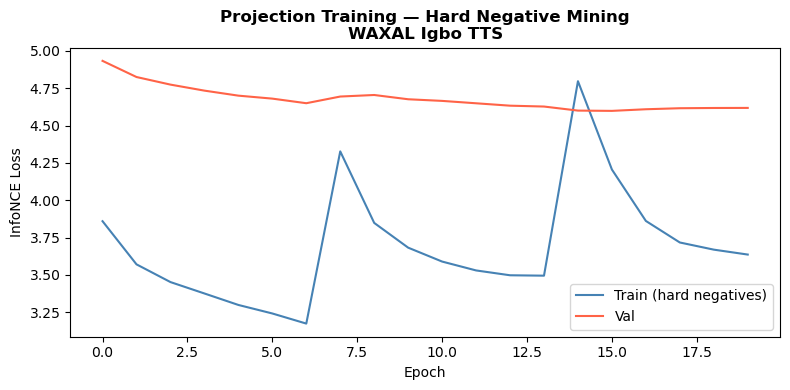

In [23]:
# ============================================================
# CELL 8B — Linear projection + InfoNCE with Hard Negative Mining
# ============================================================

import torch.nn as nn
import torch.optim as optim


class SpeechProjector(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, out_dim, bias=True),
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
        )
        nn.init.xavier_uniform_(self.proj[0].weight)
        nn.init.zeros_(self.proj[0].bias)

    def forward(self, x):
        return nn.functional.normalize(self.proj(x), dim=-1)


def infonce_loss(s, t, temp=0.07):
    """Symmetric InfoNCE — used for validation."""
    logits = (s @ t.T) / temp
    labels = torch.arange(len(s), device=s.device)
    return (nn.functional.cross_entropy(logits, labels) +
            nn.functional.cross_entropy(logits.T, labels)) / 2


def infonce_loss_with_labels(s, t, labels, temp=0.07):
    """InfoNCE with explicit labels — used when hard negatives are present."""
    logits = (s @ t.T) / temp
    return nn.functional.cross_entropy(logits, labels.to(s.device))


def mine_hard_negatives(speech_embs, text_embs, top_n=5):
    """
    For each sample i, find the top_n most similar WRONG text candidates.
    Returns hard_neg_idx of shape (N, top_n).
    """
    sim_matrix   = speech_embs @ text_embs.T
    N            = len(speech_embs)
    hard_neg_idx = np.zeros((N, top_n), dtype=np.int64)
    for i in range(N):
        sorted_idx      = np.argsort(-sim_matrix[i])
        wrong           = [idx for idx in sorted_idx if idx != i][:top_n]
        hard_neg_idx[i] = wrong
    return hard_neg_idx


def build_hard_negative_batch(local_indices, s_batch, t_batch,
                               hard_negs_batch, n_hard=2):
    """
    Build a batch of (speech, text) pairs that includes hard negatives.

    Args:
        local_indices   : [0, 1, ... B-1]
        s_batch         : (B, D) projected speech — indexed by local positions
        t_batch         : (B, D) correct text    — indexed by local positions
        hard_negs_batch : (B, top_n) global record indices of hard negatives
        n_hard          : how many hard negatives to inject per sample
    """
    s_list, t_list, label_list = [], [], []

    for pos in local_indices:
        s_list.append(s_batch[pos])         # correct speech
        t_list.append(t_batch[pos])         # correct text
        label_list.append(len(t_list) - 1)  # label = position of correct text

        for neg_global_idx in hard_negs_batch[pos][:n_hard]:
            t_list.append(T_all[neg_global_idx])  # wrong but confusable text

    s_out  = torch.stack(s_list)
    t_out  = torch.stack(t_list)
    labels = torch.tensor(label_list, dtype=torch.long)
    return s_out, t_out, labels


# ── Train / val split ─────────────────────────────────────
N      = len(records)
perm   = np.random.permutation(N)
tr_idx = perm[:int(N * 0.8)]
va_idx = perm[int(N * 0.8):]

S_all = torch.tensor(speech_embeddings, dtype=torch.float32)
T_all = torch.tensor(text_embeddings,   dtype=torch.float32)
S_va  = S_all[va_idx]
T_va  = T_all[va_idx]

print(f'Train: {len(tr_idx)} | Val: {len(va_idx)}')

# ── Initial hard negative mining ──────────────────────────
print('\nMining hard negatives from zero-shot similarity matrix...')
hard_neg_idx = mine_hard_negatives(speech_embeddings, text_embeddings, top_n=5)
print(f'Hard negatives mined. Shape: {hard_neg_idx.shape}')
print(f'Example — sample 0 hard negatives: {hard_neg_idx[0]}')

# ── Hyperparameters ───────────────────────────────────────
N_EPOCHS     = 20
BATCH_SIZE   = 32
N_HARD       = 2
LR           = 3e-4
TEMP         = 0.07
REMINE_EVERY = 7

proj  = SpeechProjector(SPEECH_EMBED_DIM, TEXT_EMBED_DIM).to(DEVICE)
opt   = optim.AdamW(proj.parameters(), lr=LR, weight_decay=1e-4)
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)

tr_losses, va_losses = [], []
best_val, best_state = float('inf'), None
t0 = time.time()

# ══════════════════════════════════════════════════════════
# EPOCH LOOP
# ══════════════════════════════════════════════════════════
for epoch in range(1, N_EPOCHS + 1):

    # Re-mine hard negatives periodically as projector improves
    if epoch > 1 and (epoch - 1) % REMINE_EVERY == 0:
        proj.eval()
        with torch.no_grad():
            s_proj_current = proj(S_all).numpy()
        hard_neg_idx = mine_hard_negatives(s_proj_current, text_embeddings, top_n=5)
        print(f'  [Epoch {epoch}] Hard negatives re-mined.')

    # ── BATCH LOOP (inside epoch loop) ────────────────────
    proj.train()
    ep_loss = 0.0
    nb      = 0
    perm_e  = np.random.permutation(len(tr_idx))

    for i in range(0, len(tr_idx), BATCH_SIZE):
        batch_local  = perm_e[i : i + BATCH_SIZE]
        batch_global = tr_idx[batch_local]

        s_proj_batch = proj(S_all[batch_global])   # (B, D)

        s_b, t_b, labels = build_hard_negative_batch(
            list(range(len(batch_global))),
            s_proj_batch.detach(),
            T_all[batch_global],
            hard_neg_idx[batch_global],
            n_hard=N_HARD,
        )

        # Re-project with gradients for backprop
        s_b  = proj(S_all[batch_global])
        loss = infonce_loss_with_labels(s_b, t_b, labels, temp=TEMP)

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(proj.parameters(), 1.0)
        opt.step()

        ep_loss += loss.item()
        nb      += 1

    # ── END OF BATCH LOOP ─────────────────────────────────
    # These lines are inside the epoch loop, outside the batch loop
    sched.step()
    avg_tr = ep_loss / nb
    tr_losses.append(avg_tr)

    # ── VALIDATION (inside epoch loop) ────────────────────
    proj.eval()
    with torch.no_grad():
        vl = infonce_loss(proj(S_va), T_va, TEMP).item()
    va_losses.append(vl)

    if vl < best_val:
        best_val   = vl
        best_state = {k: v.clone() for k, v in proj.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{N_EPOCHS} | '
              f'train: {avg_tr:.4f} | val: {vl:.4f}')

# ══════════════════════════════════════════════════════════
# END OF EPOCH LOOP
# ══════════════════════════════════════════════════════════
print(f'\nDone in {time.time()-t0:.1f}s | Best val loss: {best_val:.4f}')
proj.load_state_dict(best_state)
proj.eval()

plt.figure(figsize=(8, 4))
plt.plot(tr_losses, label='Train (hard negatives)', color='steelblue')
plt.plot(va_losses, label='Val',                    color='tomato')
plt.xlabel('Epoch'); plt.ylabel('InfoNCE Loss')
plt.title('Projection Training — Hard Negative Mining\nWAXAL Igbo TTS',
          fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('waxal_training_curve.png', dpi=100)
plt.show()

In [24]:
# ============================================================
# CELL 8C — Generate projected speech embeddings
# ============================================================

proj.eval()
with torch.no_grad():
    speech_proj = proj(
        torch.tensor(speech_embeddings, dtype=torch.float32)
    ).numpy()

sim_matrix_proj = speech_proj @ text_embeddings.T

print(f'Projected embeddings shape : {speech_proj.shape}')
print(f'Alignment (diagonal cosine sim mean):')
print(f'  Zero-shot  : {np.diag(sim_matrix_raw).mean():.4f}')
print(f'  Projected  : {np.diag(sim_matrix_proj).mean():.4f}')
print(f'  Improvement: {np.diag(sim_matrix_proj).mean() - np.diag(sim_matrix_raw).mean():+.4f}')

Projected embeddings shape : (699, 384)
Alignment (diagonal cosine sim mean):
  Zero-shot  : -0.0009
  Projected  : 0.1123
  Improvement: +0.1132


---
## STEP 9 — Benchmark Tasks

In [25]:
# ============================================================
# CELL 9A — Retrieval benchmark engine
# Pool size 100: standard protocol for cross-modal retrieval
# Each query is ranked against 1 correct + 99 distractors
# ============================================================

def run_retrieval(q_embs, c_embs, k_values=[1, 5, 10], pool_size=100, seed=SEED):
    N   = len(q_embs)
    rng = np.random.default_rng(seed)
    ranks, per_sample = [], []

    use_full = pool_size is None or pool_size >= N
    desc = f'Full pool (N={N})' if use_full else f'Pool size={pool_size}'
    print(f'  {desc}')

    for q in range(N):
        if use_full:
            pool_idx, correct_pos = np.arange(N), q
        else:
            distractors = rng.choice(
                [j for j in range(N) if j != q],
                size=pool_size - 1, replace=False
            )
            pool_idx    = np.concatenate([[q], distractors])
            correct_pos = 0

        sims  = (q_embs[q:q+1] @ c_embs[pool_idx].T).flatten()
        order = np.argsort(-sims)
        rank  = int(np.where(order == correct_pos)[0][0]) + 1

        ranks.append(rank)
        per_sample.append({
            'query_idx'  : q,
            'rank'       : rank,
            'correct_sim': float(sims[correct_pos]),
            'top1_sim'   : float(sims[order[0]]),
            'top1_cand'  : int(pool_idx[order[0]]),
        })

    ranks = np.array(ranks)
    return {
        'recall'     : {f'R@{k}': float((ranks <= k).mean()) for k in k_values},
        'mrr'        : float((1 / ranks).mean()),
        'mean_rank'  : float(ranks.mean()),
        'median_rank': float(np.median(ranks)),
        'ranks'      : ranks,
        'per_sample' : per_sample,
    }


POOL_SIZE = 100
print(f'Benchmark ready. Pool size = {POOL_SIZE}, N = {len(records)}')

Benchmark ready. Pool size = 100, N = 699


In [26]:
# ============================================================
# CELL 9B — Task 1: Speech → Text Retrieval
# ============================================================

print('=' * 55)
print(' TASK 1 — Speech → Text Retrieval')
print('=' * 55)

print('\n[A] Zero-shot:')
res_s2t_raw  = run_retrieval(speech_embeddings, text_embeddings, pool_size=POOL_SIZE)

print('\n[B] With linear projection:')
res_s2t_proj = run_retrieval(speech_proj, text_embeddings, pool_size=POOL_SIZE)

print(f"\n{'─'*45}")
print(f"  {'Metric':<18} {'Zero-shot':>12} {'Projected':>12}")
print(f"{'─'*45}")
for k in [1, 5, 10]:
    print(f"  Recall@{k:<12} "
          f"{res_s2t_raw['recall'][f'R@{k}']:>12.4f} "
          f"{res_s2t_proj['recall'][f'R@{k}']:>12.4f}")
print(f"  {'MRR':<18} {res_s2t_raw['mrr']:>12.4f} {res_s2t_proj['mrr']:>12.4f}")
print(f"  {'Mean Rank':<18} {res_s2t_raw['mean_rank']:>12.2f} {res_s2t_proj['mean_rank']:>12.2f}")
print(f"{'─'*45}")

 TASK 1 — Speech → Text Retrieval

[A] Zero-shot:
  Pool size=100

[B] With linear projection:
  Pool size=100

─────────────────────────────────────────────
  Metric                Zero-shot    Projected
─────────────────────────────────────────────
  Recall@1                  0.0129       0.0658
  Recall@5                  0.0615       0.2146
  Recall@10                 0.1116       0.3362
  MRR                      0.0580       0.1561
  Mean Rank                 49.47        25.83
─────────────────────────────────────────────


In [27]:
# ============================================================
# CELL 9C — Task 2: Text → Speech Retrieval
# ============================================================

print('=' * 55)
print(' TASK 2 — Text → Speech Retrieval')
print('=' * 55)

print('\n[A] Zero-shot:')
res_t2s_raw  = run_retrieval(text_embeddings, speech_embeddings, pool_size=POOL_SIZE)

print('\n[B] With linear projection:')
res_t2s_proj = run_retrieval(text_embeddings, speech_proj, pool_size=POOL_SIZE)

print(f"\n{'─'*45}")
print(f"  {'Metric':<18} {'Zero-shot':>12} {'Projected':>12}")
print(f"{'─'*45}")
for k in [1, 5, 10]:
    print(f"  Recall@{k:<12} "
          f"{res_t2s_raw['recall'][f'R@{k}']:>12.4f} "
          f"{res_t2s_proj['recall'][f'R@{k}']:>12.4f}")
print(f"  {'MRR':<18} {res_t2s_raw['mrr']:>12.4f} {res_t2s_proj['mrr']:>12.4f}")
print(f"  {'Mean Rank':<18} {res_t2s_raw['mean_rank']:>12.2f} {res_t2s_proj['mean_rank']:>12.2f}")
print(f"{'─'*45}")

 TASK 2 — Text → Speech Retrieval

[A] Zero-shot:
  Pool size=100

[B] With linear projection:
  Pool size=100

─────────────────────────────────────────────
  Metric                Zero-shot    Projected
─────────────────────────────────────────────
  Recall@1                  0.0129       0.0644
  Recall@5                  0.0629       0.2332
  Recall@10                 0.1259       0.3777
  MRR                      0.0616       0.1638
  Mean Rank                 46.44        23.31
─────────────────────────────────────────────


---
## STEP 10 — Evaluation Metrics

In [28]:
# ============================================================
# CELL 10A — Bootstrap confidence intervals
# ============================================================

def bootstrap_ci(values, n_boot=1000, ci=0.95, seed=SEED):
    rng   = np.random.default_rng(seed)
    means = [rng.choice(values, len(values), replace=True).mean()
             for _ in range(n_boot)]
    a = (1 - ci) / 2
    return np.percentile(means, [100*a, 50, 100*(1-a)])


def print_report(res_s2t, res_t2s, label):
    print(f"\n{'='*62}")
    print(f'  EVALUATION REPORT — {label}')
    print(f"{'='*62}")
    for direction, res in [('Speech → Text', res_s2t), ('Text → Speech', res_t2s)]:
        ranks = res['ranks']
        print(f'\n  ── {direction} ──────────────────────────')
        for k in [1, 5, 10]:
            hits = (ranks <= k).astype(float)
            lo, mn, hi = bootstrap_ci(hits)
            print(f'    Recall@{k:<5}: {mn:.4f}  (95% CI [{lo:.4f}, {hi:.4f}])')
        lo, mn, hi = bootstrap_ci(1 / ranks)
        print(f'    MRR        : {mn:.4f}  (95% CI [{lo:.4f}, {hi:.4f}])')
        print(f'    Mean Rank  : {ranks.mean():.2f}')
        print(f'    Median Rank: {np.median(ranks):.2f}')
        sims = np.array([s['correct_sim'] for s in res['per_sample']])
        print(f'    Paired sim : mean={sims.mean():.4f} | std={sims.std():.4f}')


print_report(res_s2t_raw,  res_t2s_raw,  'WAXAL Igbo TTS — Zero-shot')
print_report(res_s2t_proj, res_t2s_proj, 'WAXAL Igbo TTS — Linear Projection')


  EVALUATION REPORT — WAXAL Igbo TTS — Zero-shot

  ── Speech → Text ──────────────────────────
    Recall@1    : 0.0129  (95% CI [0.0043, 0.0215])
    Recall@5    : 0.0601  (95% CI [0.0443, 0.0801])
    Recall@10   : 0.1102  (95% CI [0.0873, 0.1359])
    MRR        : 0.0577  (95% CI [0.0483, 0.0681])
    Mean Rank  : 49.47
    Median Rank: 49.00
    Paired sim : mean=-0.0009 | std=0.0323

  ── Text → Speech ──────────────────────────
    Recall@1    : 0.0129  (95% CI [0.0057, 0.0215])
    Recall@5    : 0.0629  (95% CI [0.0457, 0.0815])
    Recall@10   : 0.1245  (95% CI [0.1001, 0.1502])
    MRR        : 0.0612  (95% CI [0.0523, 0.0715])
    Mean Rank  : 46.44
    Median Rank: 45.00
    Paired sim : mean=-0.0009 | std=0.0323

  EVALUATION REPORT — WAXAL Igbo TTS — Linear Projection

  ── Speech → Text ──────────────────────────
    Recall@1    : 0.0658  (95% CI [0.0486, 0.0858])
    Recall@5    : 0.2146  (95% CI [0.1845, 0.2432])
    Recall@10   : 0.3362  (95% CI [0.3004, 0.3705])
   

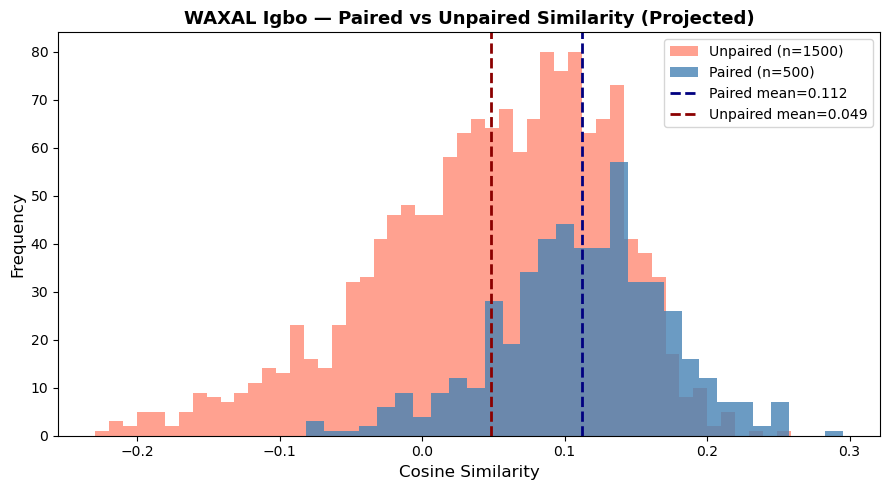

One-sided t-test (paired > unpaired):
  t-statistic : 15.9459
  p-value     : 2.81e-54
  Significant : YES ✓


In [29]:
# ============================================================
# CELL 10B — Paired vs unpaired similarity distributions
# ============================================================

N_plot  = min(500, len(records))
rng_plt = np.random.default_rng(SEED)

paired_sims   = np.diag(sim_matrix_proj[:N_plot, :N_plot])
ri  = rng_plt.integers(0, N_plot, N_plot * 5)
ci_ = rng_plt.integers(0, N_plot, N_plot * 5)
mask = ri != ci_
unpaired_sims = sim_matrix_proj[ri[mask], ci_[mask]][:N_plot * 3]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(unpaired_sims, bins=50, alpha=0.60, color='tomato',
        label=f'Unpaired (n={len(unpaired_sims)})')
ax.hist(paired_sims,   bins=30, alpha=0.80, color='steelblue',
        label=f'Paired (n={len(paired_sims)})')
ax.axvline(paired_sims.mean(),   color='navy',    lw=2, linestyle='--',
           label=f'Paired mean={paired_sims.mean():.3f}')
ax.axvline(unpaired_sims.mean(), color='darkred', lw=2, linestyle='--',
           label=f'Unpaired mean={unpaired_sims.mean():.3f}')
ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('WAXAL Igbo — Paired vs Unpaired Similarity (Projected)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('waxal_similarity_distribution.png', dpi=100)
plt.show()

t_stat, p_val = scipy_stats.ttest_ind(paired_sims, unpaired_sims, alternative='greater')
print(f'One-sided t-test (paired > unpaired):')
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_val:.2e}')
print(f'  Significant : {"YES ✓" if p_val < 0.05 else "NO ✗"}')

In [30]:
# ============================================================
# CELL 10C — Summary results table
# ============================================================

rows = []
for method, rs2t, rt2s in [
    ('Zero-shot', res_s2t_raw,  res_t2s_raw),
    ('Projected', res_s2t_proj, res_t2s_proj),
]:
    for direction, res in [('S→T', rs2t), ('T→S', rt2s)]:
        rows.append({
            'Method'   : method,
            'Direction': direction,
            'R@1'      : round(res['recall']['R@1'],  4),
            'R@5'      : round(res['recall']['R@5'],  4),
            'R@10'     : round(res['recall']['R@10'], 4),
            'MRR'      : round(res['mrr'],            4),
            'MeanRank' : round(res['mean_rank'],      2),
        })

df_results = pd.DataFrame(rows)
print('\n' + '=' * 68)
print('  WAXAL IGBO TTS — BENCHMARK SUMMARY')
print('=' * 68)
print(df_results.to_string(index=False))

df_results.to_csv('waxal_ibo_benchmark_results.csv', index=False)
print('\nSaved: waxal_ibo_benchmark_results.csv')


  WAXAL IGBO TTS — BENCHMARK SUMMARY
   Method Direction    R@1    R@5   R@10    MRR  MeanRank
Zero-shot       S→T 0.0129 0.0615 0.1116 0.0580     49.47
Zero-shot       T→S 0.0129 0.0629 0.1259 0.0616     46.44
Projected       S→T 0.0658 0.2146 0.3362 0.1561     25.83
Projected       T→S 0.0644 0.2332 0.3777 0.1638     23.31

Saved: waxal_ibo_benchmark_results.csv


---
## STEP 11 — Error Analysis

In [31]:
# ============================================================
# CELL 11A — Best and worst retrieval cases
# ============================================================

def error_analysis(results, records, q_embs, c_embs, direction, n=5):
    df = pd.DataFrame(results['per_sample'])

    print(f"\n{'═'*62}")
    print(f'  ERROR ANALYSIS — {direction}')
    print(f"{'═'*62}")

    print(f'\n✅ BEST (rank=1, n={n}):')
    for _, row in df.nsmallest(n, 'rank').iterrows():
        qi  = int(row['query_idx'])
        top = int(row['top1_cand'])
        print(f"  [rank={int(row['rank'])}]  sim={row['correct_sim']:.4f}")
        print(f"    Query : {records[qi]['text_clean'][:70]}")
        print(f"    Found : {records[top]['text_clean'][:70]}")
        print(f"    Match : {'✓ CORRECT' if top == qi else '✗ WRONG'}")
        print()

    print(f'\n❌ WORST (hardest failures, n={n}):')
    for _, row in df.nlargest(n, 'rank').iterrows():
        qi  = int(row['query_idx'])
        top = int(row['top1_cand'])
        print(f"  [rank={int(row['rank'])}]  correct_sim={row['correct_sim']:.4f}  top1_sim={row['top1_sim']:.4f}")
        print(f"    Query          : {records[qi]['text_clean'][:70]}")
        print(f"    Incorrectly got: {records[top]['text_clean'][:70]}")
        print(f"    Duration       : {records[qi]['duration']:.1f}s")
        print()


error_analysis(
    res_s2t_proj, records,
    speech_proj, text_embeddings,
    direction='Speech → Text (Projected)'
)


══════════════════════════════════════════════════════════════
  ERROR ANALYSIS — Speech → Text (Projected)
══════════════════════════════════════════════════════════════

✅ BEST (rank=1, n=5):
  [rank=1]  sim=0.2951
    Query : iko anọ akpụrụ akpụ nọ na ahere, nke na-acha nchara nchara bụ ụzọ, nke
    Found : iko anọ akpụrụ akpụ nọ na ahere, nke na-acha nchara nchara bụ ụzọ, nke
    Match : ✓ CORRECT

  [rank=1]  sim=0.2090
    Query : gurara waterfalls osimiri gurara mara oke mma, ha kpọrọ ya aha chi abụ
    Found : gurara waterfalls osimiri gurara mara oke mma, ha kpọrọ ya aha chi abụ
    Match : ✓ CORRECT

  [rank=1]  sim=0.1553
    Query : n'ubochi wenezdee, urukpu ojii ga adi n'eluigwe nke ukwuu aga enwekwa 
    Found : n'ubochi wenezdee, urukpu ojii ga adi n'eluigwe nke ukwuu aga enwekwa 
    Match : ✓ CORRECT

  [rank=1]  sim=0.1519
    Query : 1.benin 2.niger 3.chad 4.cameroon 5.togo 6.ghana 7.burkina faso 8.equa
    Found : 1.benin 2.niger 3.chad 4.cameroon 5.togo 6.ghana 7.

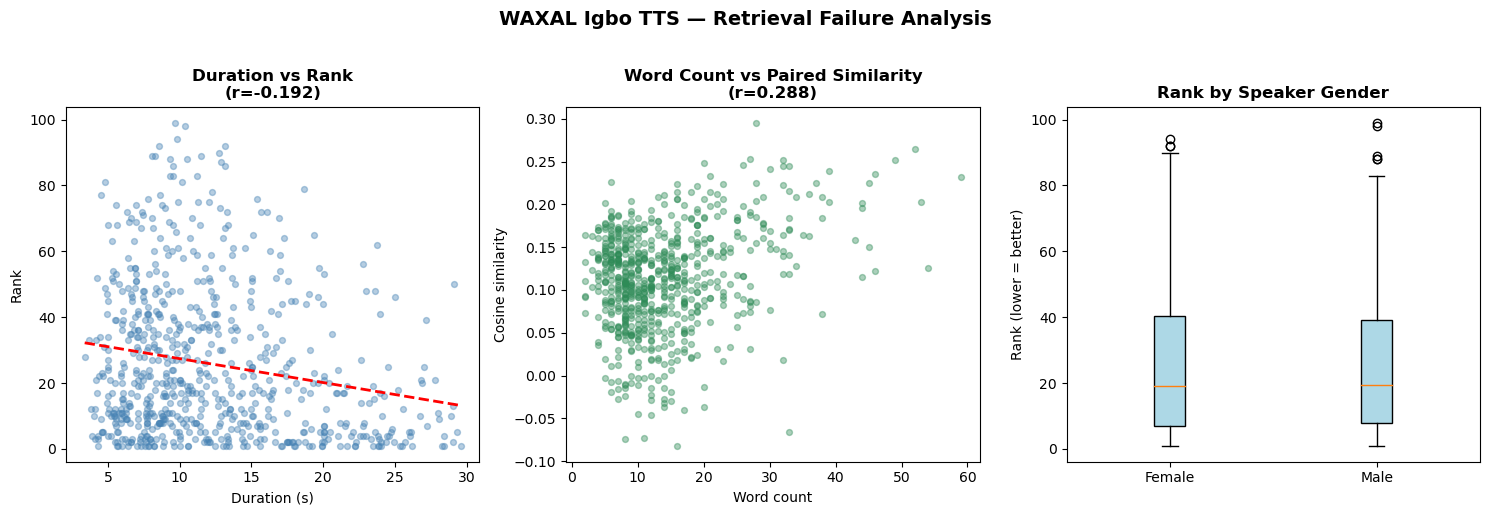

Duration–Rank correlation  : -0.1922
WordCount–Sim correlation  : 0.2884


In [32]:
# ============================================================
# CELL 11B — Correlation: what predicts failure?
# ============================================================

df_diag = pd.DataFrame([
    {
        'duration'   : records[s['query_idx']]['duration'],
        'n_words'    : len(records[s['query_idx']]['text_clean'].split()),
        'gender'     : records[s['query_idx']]['gender'],
        'rank'       : s['rank'],
        'correct_sim': s['correct_sim'],
    }
    for s in res_s2t_proj['per_sample']
])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Duration vs rank
axes[0].scatter(df_diag['duration'], df_diag['rank'], alpha=0.4, s=18, color='steelblue')
z = np.polyfit(df_diag['duration'], df_diag['rank'], 1)
xl = np.linspace(df_diag['duration'].min(), df_diag['duration'].max(), 100)
axes[0].plot(xl, np.poly1d(z)(xl), 'r--', lw=2)
r_dur = df_diag[['duration', 'rank']].corr().iloc[0, 1]
axes[0].set_title(f'Duration vs Rank\n(r={r_dur:.3f})', fontweight='bold')
axes[0].set_xlabel('Duration (s)'); axes[0].set_ylabel('Rank')

# Word count vs similarity
axes[1].scatter(df_diag['n_words'], df_diag['correct_sim'], alpha=0.4, s=18, color='seagreen')
r_wrd = df_diag[['n_words', 'correct_sim']].corr().iloc[0, 1]
axes[1].set_title(f'Word Count vs Paired Similarity\n(r={r_wrd:.3f})', fontweight='bold')
axes[1].set_xlabel('Word count'); axes[1].set_ylabel('Cosine similarity')

# Gender vs rank
genders_present = df_diag['gender'].unique().tolist()
data_by_gender  = [df_diag[df_diag['gender'] == g]['rank'].values for g in genders_present]
axes[2].boxplot(data_by_gender, labels=genders_present, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_title('Rank by Speaker Gender', fontweight='bold')
axes[2].set_ylabel('Rank (lower = better)')

plt.suptitle('WAXAL Igbo TTS — Retrieval Failure Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('waxal_error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Duration–Rank correlation  : {r_dur:.4f}')
print(f'WordCount–Sim correlation  : {r_wrd:.4f}')

---
## STEP 12 — Final Results

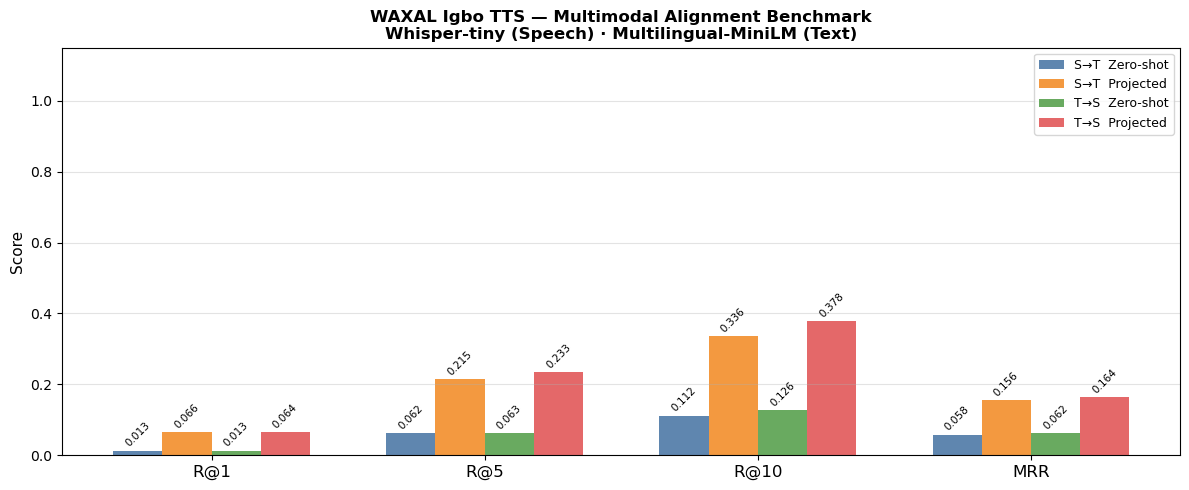

In [33]:
# ============================================================
# CELL 12A — Final benchmark bar chart
# ============================================================

metrics = ['R@1', 'R@5', 'R@10', 'MRR']

def vals(res):
    return [res['recall']['R@1'], res['recall']['R@5'],
            res['recall']['R@10'], res['mrr']]

groups = [
    ('S→T  Zero-shot', vals(res_s2t_raw),  '#4E79A7'),
    ('S→T  Projected', vals(res_s2t_proj), '#F28E2B'),
    ('T→S  Zero-shot', vals(res_t2s_raw),  '#59A14F'),
    ('T→S  Projected', vals(res_t2s_proj), '#E15759'),
]

x, w = np.arange(len(metrics)), 0.18
fig, ax = plt.subplots(figsize=(12, 5))
for i, (label, v, color) in enumerate(groups):
    bars = ax.bar(x + (i - 1.5) * w, v, width=w,
                  label=label, color=color, alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + w/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=11)
ax.set_title(
    'WAXAL Igbo TTS — Multimodal Alignment Benchmark\n'
    'Whisper-tiny (Speech) · Multilingual-MiniLM (Text)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.savefig('waxal_benchmark_final.png', dpi=120, bbox_inches='tight')
plt.show()

In [34]:
# ============================================================
# CELL 12B — Save JSON report
# ============================================================

report = {
    'project'      : 'Igbo Multimodal Semantic Alignment Benchmark',
    'dataset'      : 'google/WaxalNLP · data/TTS/ibo/',
    'provider'     : 'Media Trust Nigeria',
    'license'      : 'CC-BY-4.0',
    'total_records': 1911,
    'n_samples'    : len(records),
    'speech_model' : SPEECH_MODEL_ID,
    'text_model'   : TEXT_MODEL_ID,
    'pool_size'    : POOL_SIZE,
    'results': {
        'zero_shot': {
            'speech_to_text': {**res_s2t_raw['recall'],
                               'MRR': res_s2t_raw['mrr'],
                               'mean_rank': res_s2t_raw['mean_rank']},
            'text_to_speech': {**res_t2s_raw['recall'],
                               'MRR': res_t2s_raw['mrr'],
                               'mean_rank': res_t2s_raw['mean_rank']},
        },
        'projected': {
            'speech_to_text': {**res_s2t_proj['recall'],
                               'MRR': res_s2t_proj['mrr'],
                               'mean_rank': res_s2t_proj['mean_rank']},
            'text_to_speech': {**res_t2s_proj['recall'],
                               'MRR': res_t2s_proj['mrr'],
                               'mean_rank': res_t2s_proj['mean_rank']},
        },
    }
}

with open('waxal_ibo_final_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('Saved: waxal_ibo_final_report.json')
print('\nAll output files:')
for fname in [
    'waxal_dataset_overview.png',
    'waxal_sim_heatmap_raw.png',
    'waxal_training_curve.png',
    'waxal_similarity_distribution.png',
    'waxal_error_analysis.png',
    'waxal_benchmark_final.png',
    'waxal_ibo_benchmark_results.csv',
    'waxal_ibo_final_report.json',
    'embeddings/waxal_ibo_speech.npy',
    'embeddings/waxal_ibo_text.npy',
]:
    status = '✓' if Path(fname).exists() else '○'
    print(f'  {status} {fname}')

Saved: waxal_ibo_final_report.json

All output files:
  ✓ waxal_dataset_overview.png
  ✓ waxal_sim_heatmap_raw.png
  ✓ waxal_training_curve.png
  ✓ waxal_similarity_distribution.png
  ✓ waxal_error_analysis.png
  ✓ waxal_benchmark_final.png
  ✓ waxal_ibo_benchmark_results.csv
  ✓ waxal_ibo_final_report.json
  ✓ embeddings/waxal_ibo_speech.npy
  ✓ embeddings/waxal_ibo_text.npy
